<a href="https://colab.research.google.com/github/riannvmber/data-science-2026/blob/main/Pertemuan7_RianRamadhan_240401010021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


NAMA : RIAN RAMADHAN NIM : 240401010021 KELAS : IF403 MATA KULIAH : DATA SCIENCE

Shape: (300, 4)


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


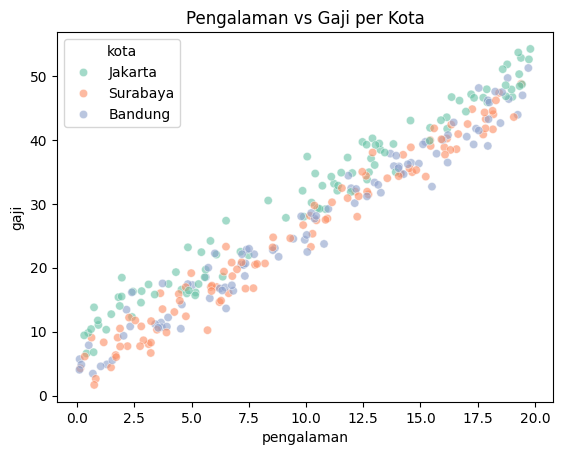

In [ ]:
# Generate Dataset & EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)

edu = np.random.choice(
    [0,1,2],
    n
)

kota = np.random.choice(
    ['Jakarta','Surabaya','Bandung'],
    n
)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota=='Jakarta',4.0,0)
    + np.random.normal(0,2,n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

print("Shape:", df.shape)

display(df.head())

print(df.describe().round(2))

sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.6
)

plt.title('Pengalaman vs Gaji per Kota')

plt.show()

In [ ]:
# Processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print("Kolom setelah encoding:")
print(df.columns.tolist())

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(
    f"Train: {X_train.shape[0]} baris, "
    f"Test: {X_test.shape[0]} baris"
)

# Scaling
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)

X_test_s = scaler.transform(X_test)

Kolom setelah encoding:
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


In [ ]:
# Latih Model Regresi Linear
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_s, y_train)

print(f'β₀ (intercept): {model.intercept_:.3f}')

print()

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values(
    'Koefisien',
    ascending=False
)

print(coef_df.to_string(index=False))

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


In [ ]:
# Evaluasi Model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Prediksi
y_pred = model.predict(X_test_s)

# Evaluasi
mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 1.649
RMSE : 2.123
R²   : 0.974


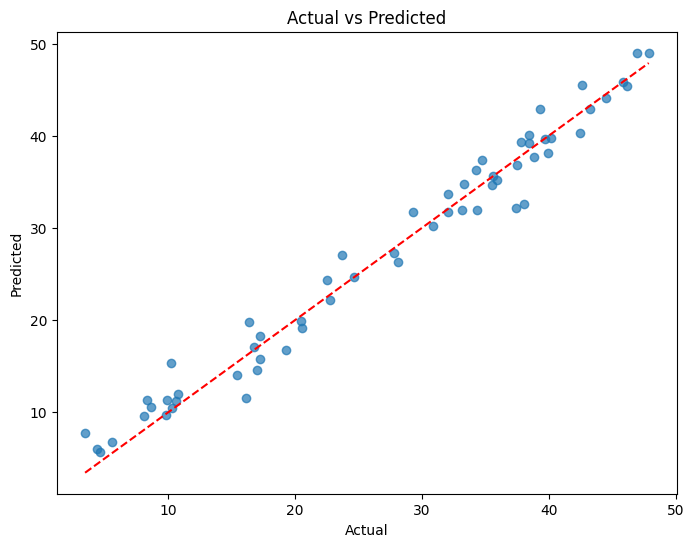

In [ ]:
# Visualisasi Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')

plt.show()

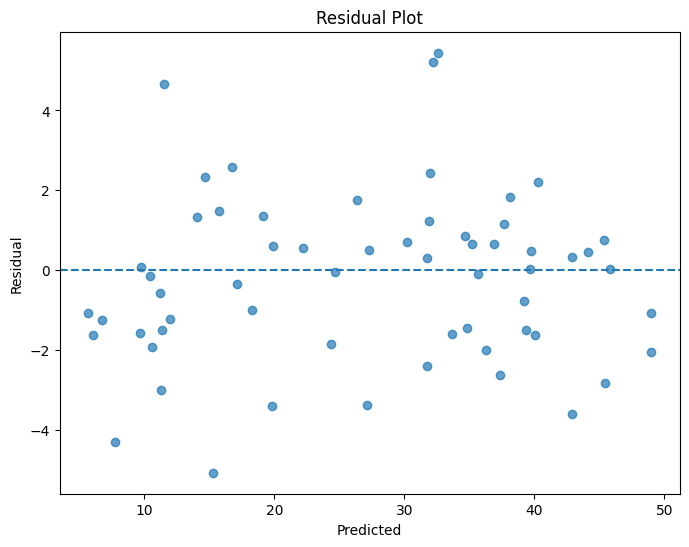

In [ ]:
# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted')
plt.ylabel('Residual')

plt.title('Residual Plot')

plt.show()

NOTE : Berdasarkan praktikum yang telah dilakukan, model Regresi Linear berhasil dibangun untuk memprediksi gaji berdasarkan pengalaman kerja, tingkat pendidikan, dan lokasi kota. Hasil evaluasi menunjukkan performa model yang sangat baik dengan nilai MAE sebesar 1.649, RMSE sebesar 2.123, dan R² sebesar 0.974. Nilai R² yang tinggi menunjukkan bahwa model mampu menjelaskan sekitar 97,4% variasi pada data gaji, sehingga prediksi yang dihasilkan memiliki tingkat akurasi yang baik.

Selain itu, analisis terhadap variabel independen menunjukkan bahwa pengalaman kerja merupakan faktor yang paling berpengaruh terhadap besarnya gaji dibandingkan tingkat pendidikan dan lokasi kota. Dengan demikian, model yang dibangun telah mampu menangkap hubungan antara variabel-variabel tersebut dengan baik dan dapat digunakan sebagai alat prediksi gaji yang efektif pada dataset yang digunakan.